# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

# **2. Import Library**

**Pada** tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Membaca Dataset
df_customer_churn = pd.read_csv("../customer_churn_raw/customer_churn.csv")
df_customer_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# Cek Informasi Dataset
df_customer_churn.info()

# Cek Statistik Dataset
display(df_customer_churn.describe().round())
df_customer_churn.describe(include='str').round()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.0,7043.0,7043.0
mean,0.0,32.0,65.0
std,0.0,25.0,30.0
min,0.0,0.0,18.0
25%,0.0,9.0,36.0
50%,0.0,29.0,70.0
75%,0.0,55.0,90.0
max,1.0,72.0,119.0


TypeError: numpy string dtypes are not allowed, use 'str' or 'object' instead

In [ ]:
# Cek Duplikat dan Missing Value
print(f'Jumlah Duplikat      : {df_customer_churn.duplicated().sum()}')
print(f'Jumlah Missing Value : \n{df_customer_churn.isna().sum()}')

Jumlah Duplikat      : 0
Jumlah Missing Value : 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


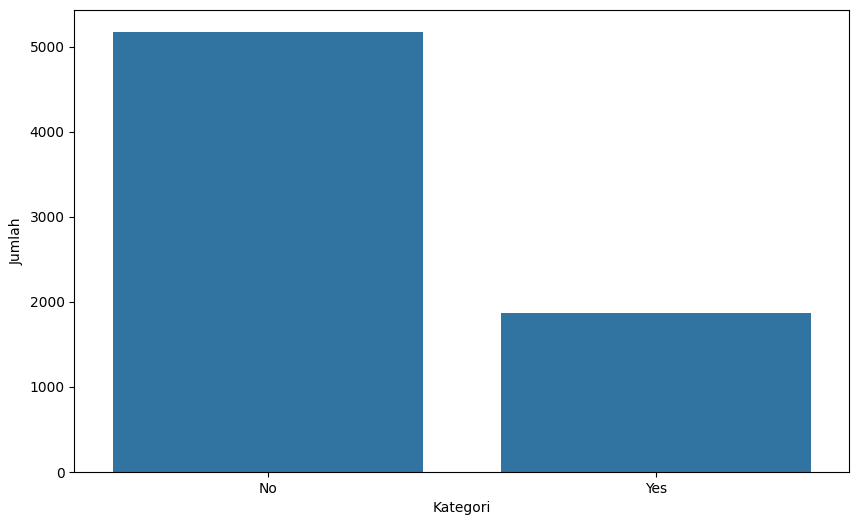

In [ ]:
# Visualisasi Jumlah Kategori Churn
plt.figure(figsize=(10,6), dpi=100)
sns.countplot(data=df_customer_churn, x='Churn')
plt.xlabel('Kategori')
plt.ylabel('Jumlah')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# Menghapus Kolom Customer ID
df_customer_churn.drop(columns=['customerID'], inplace=True)

# Merubah Kolom TotalChargers Menjadi Numerik
df_customer_churn['TotalCharges'] = pd.to_numeric(df_customer_churn['TotalCharges'], errors='coerce')
df_customer_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [ ]:
# Mengatasi Missing Value Kolom Total Charges
df_customer_churn['TotalCharges'] = df_customer_churn['TotalCharges'].fillna(df_customer_churn['TotalCharges'].median())
df_customer_churn.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

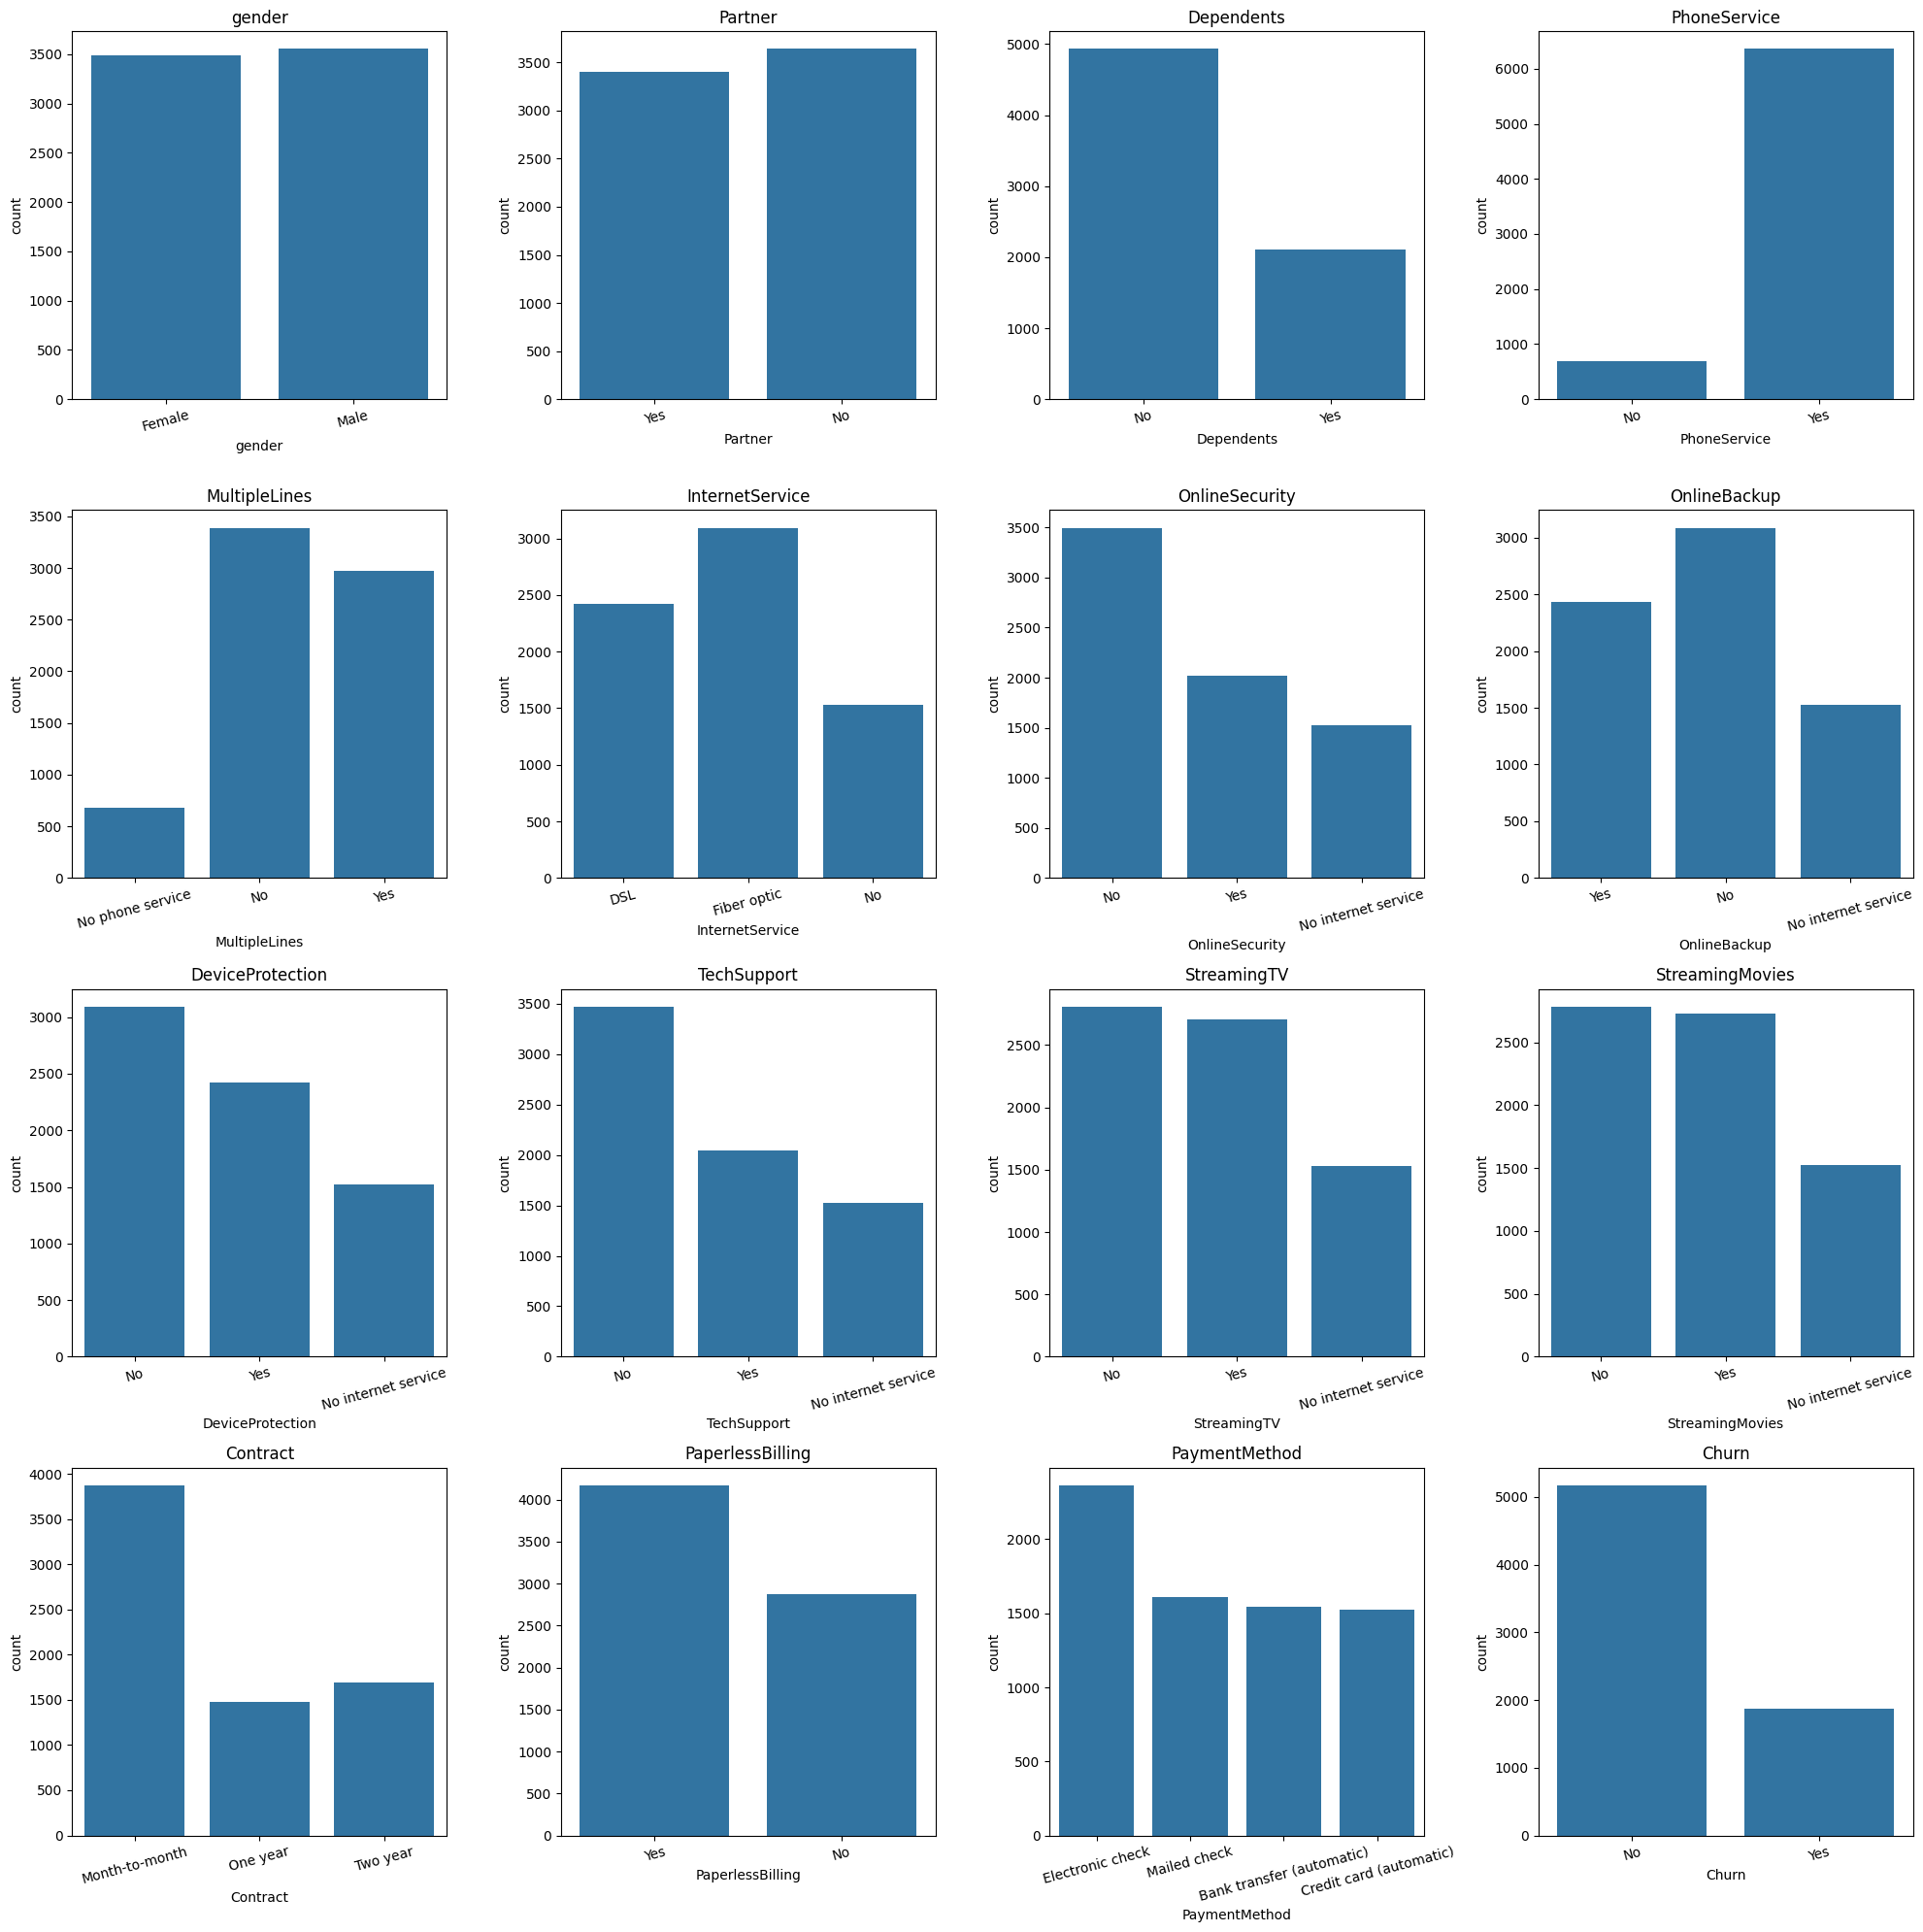

In [ ]:
# Visualisasi Kolom Kategorical
kolom_kategori = df_customer_churn.select_dtypes('str').columns
jumlah_kolom = 4
jumlah_baris = math.ceil(len(kolom_kategori)/jumlah_kolom)

# Membuat Canvas
fig, ax = plt.subplots(jumlah_baris, jumlah_kolom, figsize=(20, jumlah_baris*5), dpi = 100)
ax = ax.flatten()

# Membuat Visualisasi
for i, kolom in enumerate(kolom_kategori) : 
    sns.countplot(data=df_customer_churn, x=kolom, ax=ax[i])
    ax[i].set_title(kolom)
    ax[i].tick_params(axis='x', rotation=15)

# Menghilangkan Sisa Kolom
for i in range(len(kolom_kategori), len(ax)) : 
    fig.delaxes(ax[i])

# Menampilkan Visualisasi
plt.tight_layout()
plt.show()

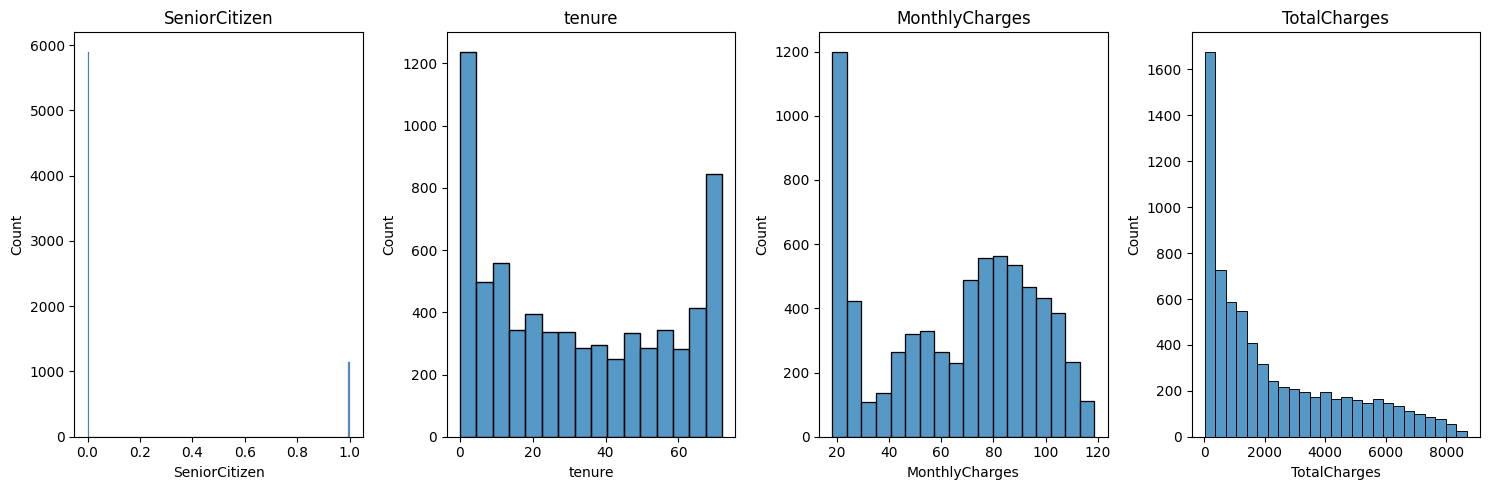

In [ ]:
# Visualisasi Kolom Numerik
kolom_numerik = df_customer_churn.select_dtypes('number').columns

# Membuat Canvas
fig, ax = plt.subplots(1, 4, figsize=(15, 5), dpi = 100)
ax = ax.flatten()

# Membuat Visualisasi
for i, kolom in enumerate(kolom_numerik) : 
    sns.histplot(data=df_customer_churn, x=kolom, ax=ax[i])
    ax[i].set_title(kolom)

# Menghilangkan Sisa Kolom
for i in range(len(kolom_numerik), len(ax)) : 
    fig.delaxes(ax[i])

# Menampilkan Visualisasi
plt.tight_layout()
plt.show()

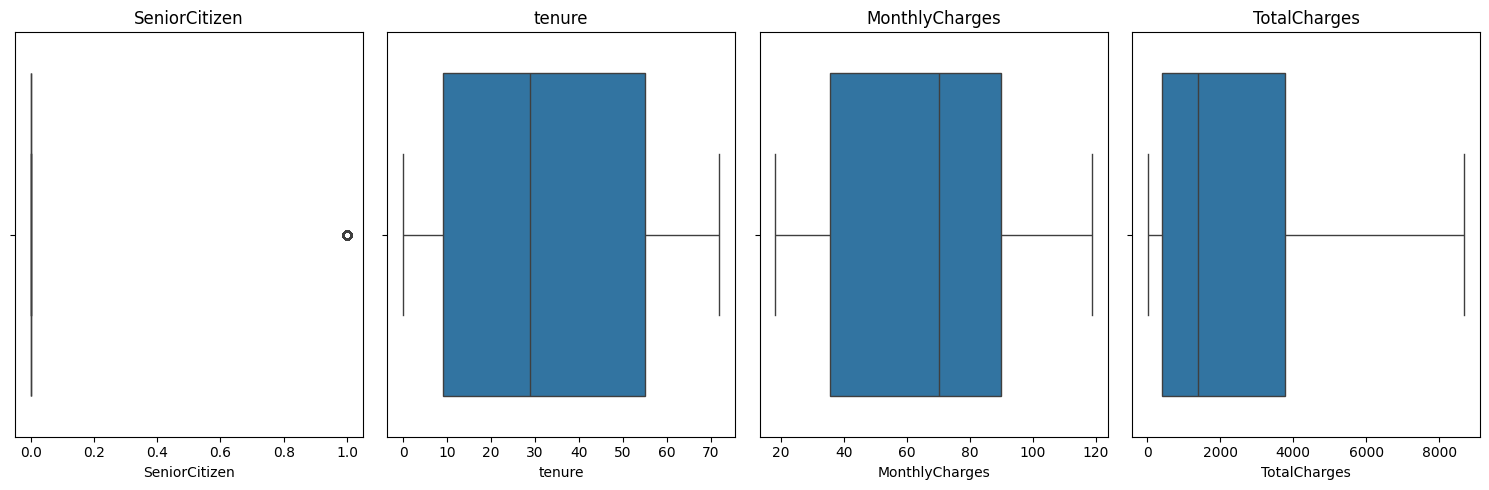

In [ ]:
# Visualisasi Cek Outlier
# Membuat Canvas
fig, ax = plt.subplots(1, 4, figsize=(15, 5), dpi = 100)
ax = ax.flatten()

# Membuat Visualisasi
for i, kolom in enumerate(kolom_numerik) : 
    sns.boxplot(data=df_customer_churn, x=kolom, ax=ax[i])
    ax[i].set_title(kolom)

# Menghilangkan Sisa Kolom
for i in range(len(kolom_numerik), len(ax)) : 
    fig.delaxes(ax[i])

# Menampilkan Visualisasi
plt.tight_layout()
plt.show()

In [ ]:
# Mengubah Kolom Churn
df_customer_churn['Churn'] = df_customer_churn['Churn'].map({
    'Yes' : 1,
    'No' : 0
})

# Memisahkan Kolom 2 kategori dan 3 Kategori
kolom_2_kategori = []
kolom_multikategori = []

for kolom in kolom_kategori : 
    if df_customer_churn[kolom].nunique() == 2 : 
        kolom_2_kategori.append(kolom)
    else : 
        kolom_multikategori.append(kolom)

# Encoding Kolom 2 Kategori
for kolom in kolom_2_kategori : 
    nilai_unik = sorted(df_customer_churn[kolom].unique())

    # Mappping
    mapping = {
        nilai_unik[0]: 0,
        nilai_unik[1]: 1
    }

    df_customer_churn[kolom] = df_customer_churn[kolom].map(mapping)

# Encoding Kolom Multikategori
df_customer_churn = pd.get_dummies(df_customer_churn, columns=kolom_multikategori, drop_first=True)

# Menampilkan Data
df_customer_churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Simpan Dataset
df_customer_churn.to_csv(
    "customer_churn_preprocessing.csv",
    index=False
)